In [1]:
print("박세훈")

박세훈


In [2]:
import pandas as pd

In [3]:
# train = pd.read_csv("score_train.csv")

In [4]:
# test = pd.read_csv("score_test.csv")


In [5]:
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_train.csv")


In [6]:
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_test.csv")


In [7]:
print("===== 데이터 크기 =====")


===== 데이터 크기 =====


In [8]:
print("Train Shape:", train.shape)


Train Shape: (4198, 21)


In [9]:
print("Test Shape:", test.shape)


Test Shape: (1499, 20)


In [10]:
print("\n") # 줄 바꿈

In [11]:
print("===== 데이터 정보(자료형) =====")



===== 데이터 정보(자료형) =====


In [12]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4198 entries, 0 to 4197
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Delay_from_due_date       4198 non-null   float64
 1   Num_of_Delayed_Payment    4198 non-null   float64
 2   Num_Credit_Inquiries      4198 non-null   float64
 3   Credit_Utilization_Ratio  4198 non-null   float64
 4   Credit_History_Age        4198 non-null   float64
 5   Payment_of_Min_Amount     4198 non-null   object 
 6   Amount_invested_monthly   4198 non-null   float64
 7   Monthly_Balance           4198 non-null   float64
 8   Credit_Mix                4198 non-null   object 
 9   Payment_Behaviour         4198 non-null   object 
 10  Age                       4198 non-null   float64
 11  Annual_Income             4198 non-null   float64
 12  Num_Bank_Accounts         4198 non-null   float64
 13  Num_Credit_Card           4198 non-null   float64
 14  Interest

In [13]:
print("\n")

In [14]:
print("===== train 결측치 수 =====")

===== train 결측치 수 =====


In [15]:
print(train.isnull().sum().sum())


0


In [16]:
print("\n")

In [17]:
print("===== test 결측치 수 =====")


===== test 결측치 수 =====


In [18]:
print(test.isnull().sum().sum())


0


In [19]:
print("\n")


In [20]:
print("===== target 빈도 =====")



===== target 빈도 =====


In [21]:
print(train['Credit_Score'].value_counts())


Credit_Score
Standard    2225
Poor        1232
Good         741
Name: count, dtype: int64


In [24]:
target = train.pop('Credit_Score')

In [25]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)


In [28]:
print("\n ===== 분할된 데이터 크기 =====")



 ===== 분할된 데이터 크기 =====


In [29]:
print(X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)

(3358, 29) (840, 29) (3358,) (840,)


In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf = RandomForestClassifier(random_state=0)

In [32]:
rf.fit(X_tr, y_tr)

RandomForestClassifier(random_state=0)

In [33]:
pred = rf.predict(X_val)

In [34]:
from sklearn.metrics import f1_score

In [35]:
f1 = f1_score(y_val, pred, average='macro')


In [37]:
print('\n f1-macro:', f1)



 f1-macro: 0.7004593488873695


In [38]:
pred = rf.predict(test)
submit = pd.DataFrame({'pred':pred})
submit.to_csv("result.csv", index=False)



In [39]:
print("\n ===== 제출파일 (샘플 5개) =====")
print(pd.read_csv("result.csv").head())


 ===== 제출파일 (샘플 5개) =====
       pred
0      Poor
1      Good
2  Standard
3      Good
4  Standard


In [40]:
print("풀이2")

풀이2


In [41]:
import pandas as pd
# train = pd.read_csv("train.csv")
# test = pd.read_csv("ltest.csv")

In [42]:
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")


In [43]:
train.shape, test.shape


((3759, 9), (1617, 8))

In [44]:
train.head(3)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,EcoSport,2017,10298,Manual,25013,Petrol,150,53.3,1.0
1,Focus,2016,10491,Manual,30970,Diesel,0,74.3,1.5
2,S-MAX,2017,13498,Manual,60200,Diesel,150,56.5,2.0


In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3759 non-null   object 
 1   year          3759 non-null   int64  
 2   price         3759 non-null   int64  
 3   transmission  3759 non-null   object 
 4   mileage       3759 non-null   int64  
 5   fuelType      3759 non-null   object 
 6   tax           3759 non-null   int64  
 7   mpg           3759 non-null   float64
 8   engineSize    3759 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 264.4+ KB


In [46]:
train.describe()

,year,price,mileage,tax,mpg,engineSize
count,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000
mean,2016.887736,12353.321362,23191.786379,114.444001,57.793083,1.352807
std,2.151811,4750.338051,19223.258713,61.713682,10.099221,0.437130
min,2002.000000,1095.000000,5.000000,0.000000,20.900000,0.000000
25%,2016.000000,9000.000000,9997.500000,75.000000,52.300000,1.000000
50%,2017.000000,11495.000000,18180.000000,145.000000,58.900000,1.200000
75%,2018.000000,15310.000000,31000.000000,145.000000,65.700000,1.500000
max,2060.000000,48000.000000,144000.000000,570.000000,201.800000,5.000000


In [48]:
train.describe(include='O')

,model,transmission,fuelType
count,3759,3759,3759
unique,19,3,3
top,Fiesta,Manual,Petrol
freq,1372,3234,2541


In [51]:
train.isnull().sum().sum()

np.int64(0)

In [52]:
test.isnull().sum().sum()

np.int64(0)

In [53]:


train['price'].value_counts()


,count
price,
12000,33
9000,31
11000,30
11500,27
10000,27
...,...
5700,1
7481,1
8194,1


<Axes: >

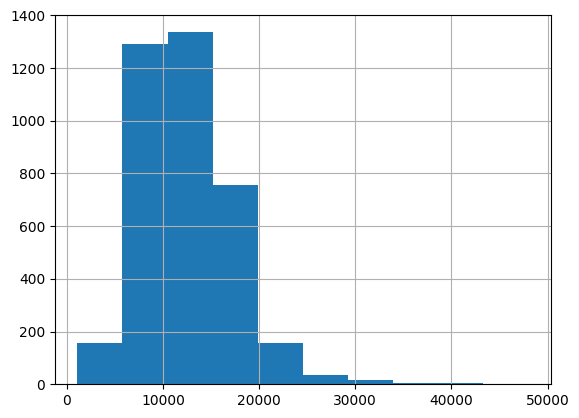

In [54]:

train['price'].hist()

In [55]:
target = train.pop('price')

print(train.shape, test.shape)
train = pd.get_dummies(train)
test = pd.get_dummies(test)
print(train.shape, test.shape)

(3759, 8) (1617, 8)
(3759, 30) (1617, 30)


In [56]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape


((3007, 30), (752, 30), (3007,), (752,))

In [57]:
from sklearn.metrics import root_mean_squared_error

In [58]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
pred = lr.predict(X_val)
root_mean_squared_error(y_val, pred)

1862.2289379589881

In [60]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)
root_mean_squared_error(y_val, pred)

1341.943732584459

In [61]:
pred = rf.predict(test)
submit = pd.DataFrame({'pred':pred})
submit.to_csv("result.csv", index=False)

In [62]:
print(pd.read_csv("result.csv").head())

       pred
0  15586.88
1  15407.71
2  14912.47
3  18482.73
4   6168.01
